Varianza explicada por componente (ratio): [0.7296 0.2285 0.0367 0.0052]
Varianza explicada acumulada: [0.7296 0.9581 0.9948 1.    ]


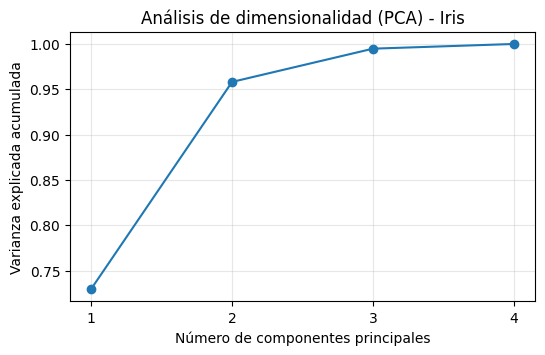


--- Componentes principales elegidos ---

Componentes principales elegidos (primeras 2):
PC1: sepal length (cm): 0.521, sepal width (cm): -0.269, petal length (cm): 0.580, petal width (cm): 0.565
PC2: sepal length (cm): 0.377, sepal width (cm): 0.923, petal length (cm): 0.024, petal width (cm): 0.067

Asociación de Componentes Principales con características originales:
PC1 está más asociada con: petal length (cm), petal width (cm), sepal length (cm), sepal width (cm)
PC2 está más asociada con: sepal width (cm), sepal length (cm), petal width (cm), petal length (cm)
Adjusted Rand Index - KMeans: 0.6201, GMM: 0.5149
Silhouette Score (2D PCA) - KMeans: 0.5092, GMM: 0.4677


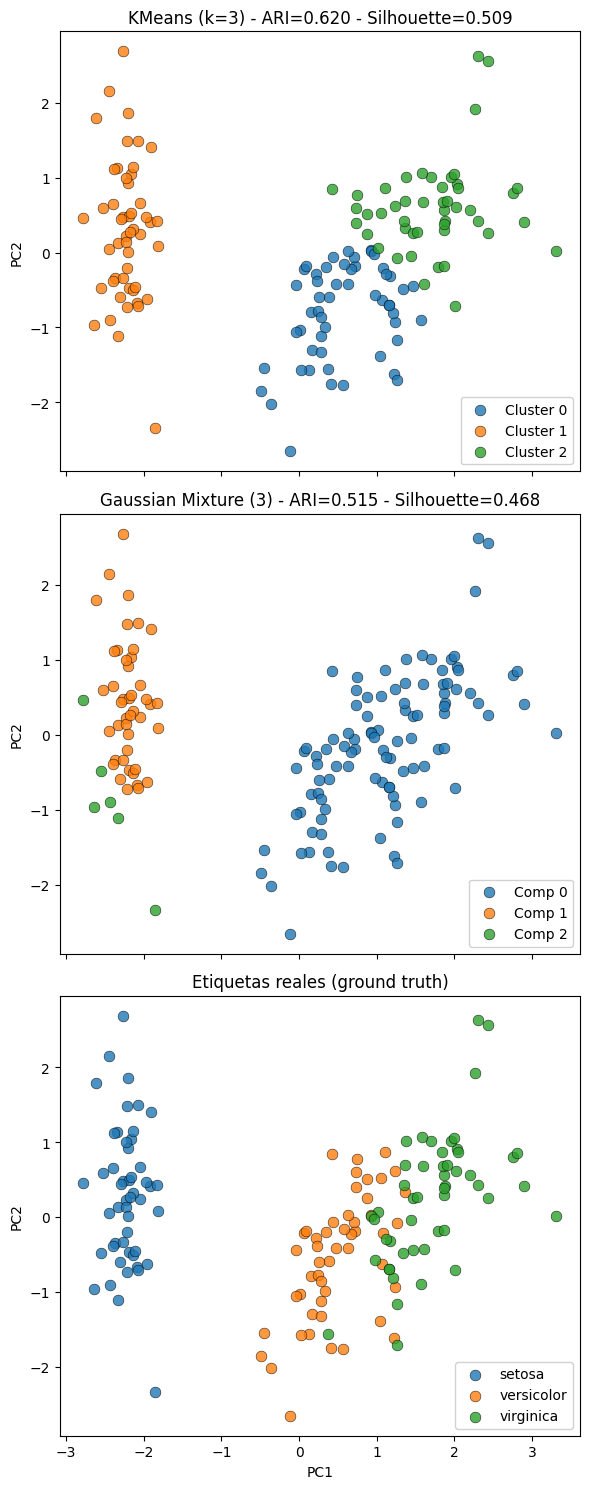


Observaciones:
- PCA indica cuánta varianza se retiene cuando se reduce dimensionalidad.
- En Iris, 2-3 componentes suelen capturar gran parte de la varianza.
- KMeans y GMM producen particiones similares; comparar ARI y Silhouette para evaluar.
- Si hay nulos se imputó por la media antes de estandarizar.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score


# Nota: si hay valores nulos se imputan por la media.

# Importaciones
import matplotlib.pyplot as plt

# reproducibilidad: usa RND si existe en el entorno, si no, 42
RANDOM_STATE = globals().get("RND", 42)

# 1) Cargar dataset iris y crear DataFrame
data = load_iris()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
target_names = data.target_names

# añadir la columna objetivo para referencia
df = X_raw.copy()
df["species"] = pd.Categorical.from_codes(y, target_names)

# 2) Imputación de nulos (si existieran) usando la media
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(df[data.feature_names])

# 3) Estandarización de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4) Análisis de dimensionalidad con PCA completo
pca_full = PCA()
pca_full.fit(X_scaled)
explained_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

# Mostrar varianza explicada por componente
print("Varianza explicada por componente (ratio):", np.round(explained_ratio, 4))
print("Varianza explicada acumulada:", np.round(cum_explained, 4))

# 4a) Gráfico de Scree / varianza acumulada
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(explained_ratio) + 1), cum_explained, marker="o")
plt.xticks(range(1, len(explained_ratio) + 1))
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Análisis de dimensionalidad (PCA) - Iris")
plt.grid(alpha=0.3)
plt.show()

# 5) Reducción de dimensionalidad: elegir 2 componentes para visualización y clusterización
n_components = 2
pca_2 = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca2 = pca_2.fit_transform(X_scaled)


# mostrar cuales son los componentes elegidos del dataset original
print("\n--- Componentes principales elegidos ---\n")
print(f"Componentes principales elegidos (primeras {n_components}):")
for i in range(n_components):
    component = pca_2.components_[i]
    feature_contributions = ", ".join(
        f"{feat}: {weight:.3f}" for feat, weight in zip(data.feature_names, component)
    )
    print(f"PC{i+1}: {feature_contributions}")

# mostrar los nombres reales de las columnas que estan asociadas a cada CP
print("\nAsociación de Componentes Principales con características originales:")
for i in range(n_components):
    component = pca_2.components_[i]
    top_features_indices = np.argsort(np.abs(component))[::-1]
    top_features = [data.feature_names[idx] for idx in top_features_indices]
    print(f"PC{i+1} está más asociada con: {', '.join(top_features)}")
    
# -----------------

# 6) Clusterización con KMeans (k=3)
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca2)

# 7) Clusterización con Gaussian Mixture (3 componentes)
gmm = GaussianMixture(n_components=3, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_pca2)

# 8) Métricas de comparación (ajuste frente a etiquetas reales)
ari_kmeans = adjusted_rand_score(y, kmeans_labels)
ari_gmm = adjusted_rand_score(y, gmm_labels)

# Silhouette (en el espacio PCA 2D)
sil_kmeans = silhouette_score(X_pca2, kmeans_labels)
sil_gmm = silhouette_score(X_pca2, gmm_labels)

print(f"Adjusted Rand Index - KMeans: {ari_kmeans:.4f}, GMM: {ari_gmm:.4f}")
print(f"Silhouette Score (2D PCA) - KMeans: {sil_kmeans:.4f}, GMM: {sil_gmm:.4f}")

# 9) Visualización: 3 gráficos en 1 columna (KMeans, GMM, Etiquetas reales)
palette = sns.color_palette("tab10", 3)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 15), sharex=True, sharey=True)

scatter_kwargs = dict(s=60, alpha=0.8, edgecolors="k", linewidth=0.4)

# KMeans plot
ax = axes[0]
for lbl in np.unique(kmeans_labels):
    mask = kmeans_labels == lbl
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=f"Cluster {lbl}", color=palette[lbl], **scatter_kwargs)
ax.set_title(f"KMeans (k=3) - ARI={ari_kmeans:.3f} - Silhouette={sil_kmeans:.3f}")
ax.set_ylabel("PC2")
ax.legend(loc="best", framealpha=0.9)

# GMM plot
ax = axes[1]
for lbl in np.unique(gmm_labels):
    mask = gmm_labels == lbl
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=f"Comp {lbl}", color=palette[lbl], **scatter_kwargs)
ax.set_title(f"Gaussian Mixture (3) - ARI={ari_gmm:.3f} - Silhouette={sil_gmm:.3f}")
ax.set_ylabel("PC2")
ax.legend(loc="best", framealpha=0.9)

# Etiquetas reales plot
ax = axes[2]
for lbl in np.unique(y):
    mask = y == lbl
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=target_names[lbl], color=palette[lbl], **scatter_kwargs)
ax.set_title("Etiquetas reales (ground truth)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(loc="best", framealpha=0.9)

plt.tight_layout()
plt.show()

# 10) Observaciones breves (imprimir)
print("\nObservaciones:")
print("- PCA indica cuánta varianza se retiene cuando se reduce dimensionalidad.")
print("- En Iris, 2-3 componentes suelen capturar gran parte de la varianza.")
print("- KMeans y GMM producen particiones similares; comparar ARI y Silhouette para evaluar.")
print("- Si hay nulos se imputó por la media antes de estandarizar.")